# Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
import seaborn as sb

# Load Dataset

In [13]:
df=pd.read_csv('heart.csv.xls')

# sample data

In [14]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
479,58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
232,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
673,54,1,2,120,258,0,0,147,0,0.4,1,0,3,1
496,68,1,2,180,274,1,0,150,1,1.6,1,0,3,0


# check for missing values

In [17]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# **EDA**

/tmp/ipython-input-14864683.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='target',data=df,palette='Blues',color="red")


<Axes: xlabel='target', ylabel='count'>

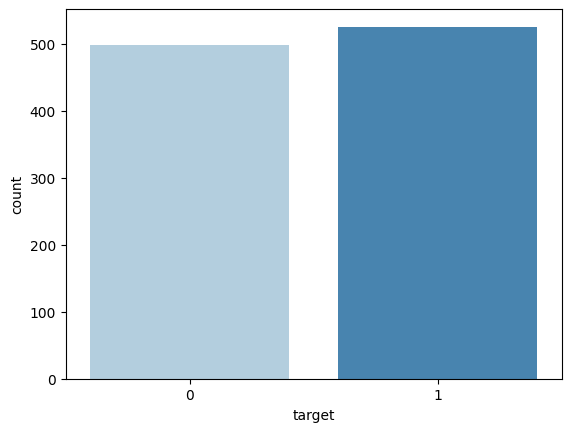

In [18]:
sb.countplot(x='target',data=df,palette='Blues',color="red")

<Axes: xlabel='age_group', ylabel='count'>

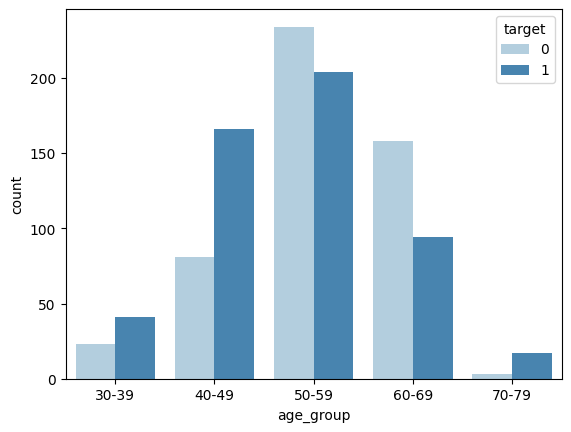

In [19]:
bins=[29,40,50,60,70,80]
labels=["30-39","40-49","50-59","60-69","70-79"]
df["age_group"]=pd.cut(df["age"],bins=bins,labels=labels)
sb.countplot(x="age_group",hue="target",data=df,palette="Blues",color="red")

## Prepare Data for Modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Drop the 'age_group' column as it was created for EDA and 'target' which is our dependent variable
X = df.drop(['target', 'age_group'], axis=1)
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (820, 13)
X_test shape: (205, 13)
y_train shape: (820,)
y_test shape: (205,)


## Train Model and Calculate Accuracy

In [21]:
# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7951


In [22]:
import joblib
joblib.dump(model,'logistic_regression model.pkl')
print("model saved successfully")

model saved successfully
